In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [82]:
df = pd.read_csv(r"C:\Users\manik\Downloads\usa_rain_prediction_dataset_2024_2025.csv")
print("\n Columns")
for col in df.columns:
    print(col)


 Columns
Date
Location
Temperature
Humidity
Wind Speed
Precipitation
Cloud Cover
Pressure
Rain Tomorrow


In [83]:
target_col = None

for col in df.columns:
    col_lower = col.lower()
    if "rain" in col_lower and ("tomorrow" in col_lower or df[col].nunique() <= 2):
        target_col = col
        break

if target_col is None:
    raise ValueError("Target column not found automatically")

print(f"\nDetected Target Column: {target_col}")


Detected Target Column: Rain Tomorrow


In [84]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
le = LabelEncoder()
if 'Location' in df.columns:
    df['Location'] = le.fit_transform(df['Location'])
if df[target_col].dtype == 'object':
    df[target_col] = le.fit_transform(df[target_col])

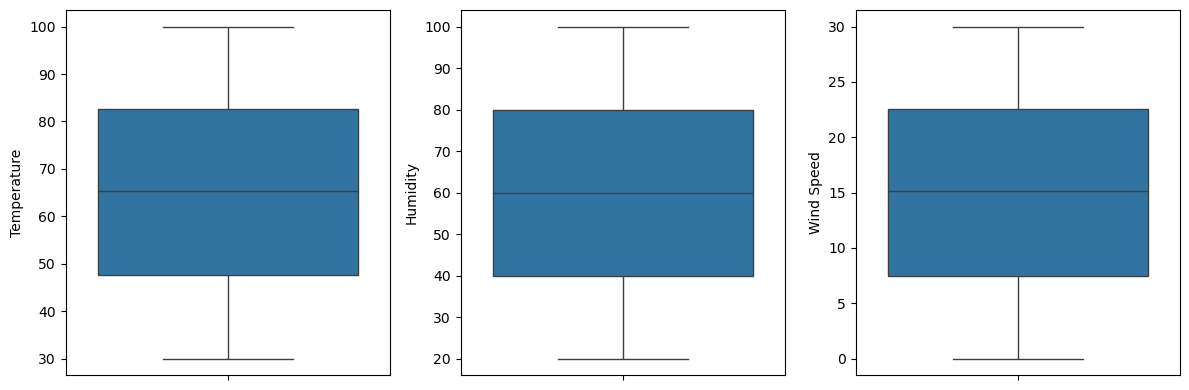

In [68]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Temperature'])

plt.subplot(1,3,2)
sns.boxplot(y=df['Humidity'])

plt.subplot(1,3,3)
sns.boxplot(y=df['Wind Speed'])

plt.tight_layout()
plt.show()


In [69]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if col != target_col:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])

In [70]:
x = df.drop([target_col, 'Date'], axis=1, errors='ignore')
y = df[target_col]
print("\nTarget Distribution:")
print(y.value_counts())


Target Distribution:
Rain Tomorrow
0    56988
1    16112
Name: count, dtype: int64


In [71]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [72]:
scaler = MinMaxScaler()
x_train_mm = scaler.fit_transform(x_train)
x_test_mm = scaler.transform(x_test)

In [73]:
lr = LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(x_train_mm, y_train)
lr_pred = lr.predict(x_test_mm)

In [74]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)

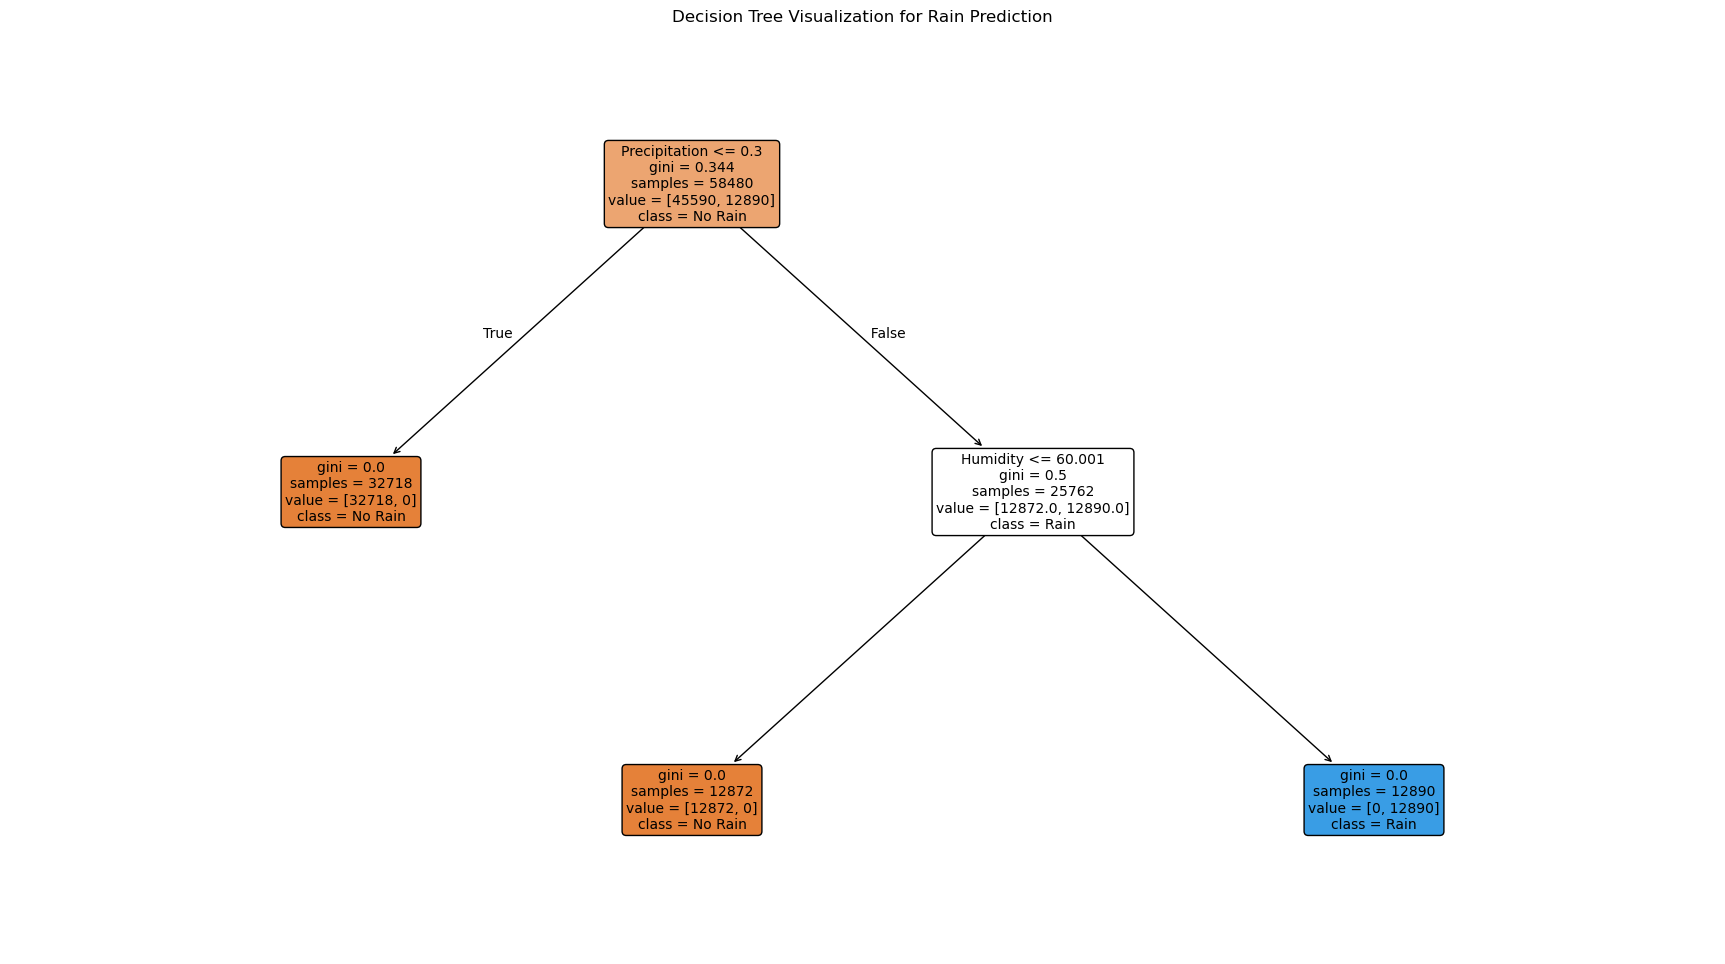

In [75]:
plt.figure(figsize=(22, 12))
plot_tree(dt,feature_names=x.columns,class_names=['No Rain', 'Rain'],filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree Visualization for Rain Prediction")
plt.show()

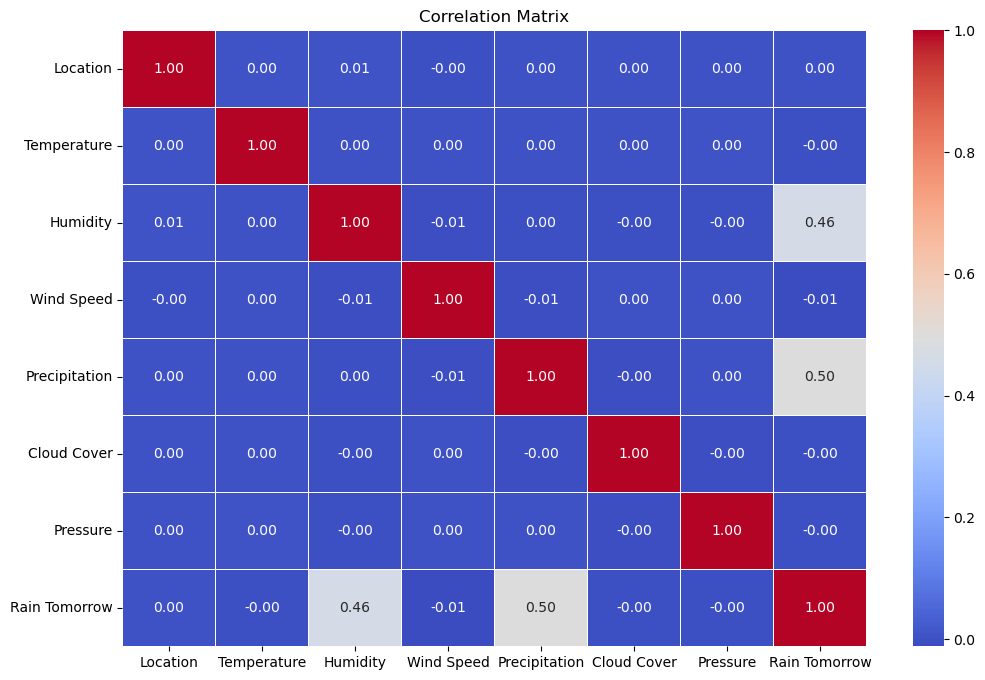

In [76]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
k_values = range(1, 21)
knn_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_mm, y_train)
    pred = knn.predict(X_test_mm)
    knn_acc.append(accuracy_score(y_test, pred))

plt.plot(k_values, knn_acc, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)
plt.show()

kval= k_values[np.argmax(knn_acc)]
print("\nKval:", kval)

In [78]:
knn_best = KNeighborsClassifier(n_neighbors=kval)
knn_best.fit(x_train_mm, y_train)
knn_pred = knn_best.predict(x_test_mm)

In [79]:
rf = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [80]:
print("\nMODEL ACCURACY")
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("KNN:", accuracy_score(y_test, knn_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

print("\n Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))




MODEL ACCURACY
Logistic Regression: 0.8646374829001368
Decision Tree: 1.0
KNN: 0.9740766073871409
Random Forest: 1.0

 Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11398
           1       1.00      1.00      1.00      3222

    accuracy                           1.00     14620
   macro avg       1.00      1.00      1.00     14620
weighted avg       1.00      1.00      1.00     14620


Confusion Matrix
[[11398     0]
 [    0  3222]]
